# QCPO Sweep Analysis Report

This notebook analyzes the hyperparameter sweep results for QCPO on the ToyEnv.
It loads data from the `wandb` local directory, visualizes parameter impacts, and suggests optimal configurations.

In [31]:
import os
import json
import yaml
import glob
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set style
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = [10, 6]

## 1. Load Data from WandB Local Directory

In [32]:
# Paths
WANDB_DIR = 'wandb'
RUNS_PATTERN = os.path.join(WANDB_DIR, 'run-*')

def load_run_data(run_path):
    files_dir = os.path.join(run_path, 'files')
    config_path = os.path.join(files_dir, 'config.yaml')
    summary_path = os.path.join(files_dir, 'wandb-summary.json')

    if not os.path.exists(config_path) or not os.path.exists(summary_path):
        return None

    try:
        # Load Config
        with open(config_path, 'r') as f:
            config_data = yaml.safe_load(f)
        
        params = {}
        if config_data:
            for key, value in config_data.items():
                if isinstance(value, dict) and 'value' in value:
                    params[key] = value['value']
                else:
                    params[key] = value

        # Load Summary
        with open(summary_path, 'r') as f:
            summary_data = json.load(f)
        
        # Combine
        data = params.copy()
        for k, v in summary_data.items():
            data[f"metric_{k}"] = v
            
        data['run_id'] = os.path.basename(run_path)
        return data

    except Exception as e:
        # print(f"Error loading {run_path}: {e}")
        return None

# Load all runs
run_dirs = glob.glob(RUNS_PATTERN)
runs_data = []
sweep_params = ['outer_interval', 'nu', 'lambda_max', 'quantile_threshold']

print(f"Scanning {len(run_dirs)} runs...")

for run_dir in run_dirs:
    data = load_run_data(run_dir)
    if data:
        # Check if this run looks like part of the sweep (has all params)
        if all(p in data for p in sweep_params):
            runs_data.append(data)

df = pd.DataFrame(runs_data)
metric_col = 'metric_error/weights'

# Clean Data
if metric_col in df.columns:
    df[metric_col] = pd.to_numeric(df[metric_col], errors='coerce')
    df = df.dropna(subset=[metric_col])
    print(f"Loaded {len(df)} valid sweep runs.")
else:
    print("Metric column not found!")

Scanning 274 runs...
Loaded 260 valid sweep runs.


## 2. Best Configuration

In [33]:
best_run = df.loc[df[metric_col].idxmin()]

print("Best Run ID:", best_run['run_id'])
print(f"Best Score ({metric_col}):", best_run[metric_col])
print("\nParameters:")
for p in sweep_params:
    print(f"  {p}: {best_run[p]}")

Best Run ID: run-20251122_025339-8psf51kl
Best Score (metric_error/weights): 0.03294979999367307

Parameters:
  outer_interval: 100
  nu: 0.1
  lambda_max: 100
  quantile_threshold: -5.0


## 3. Parameter Impact Analysis
We visualize how each parameter affects the target metric (error/weights).
**Goal:** Minimize the metric.

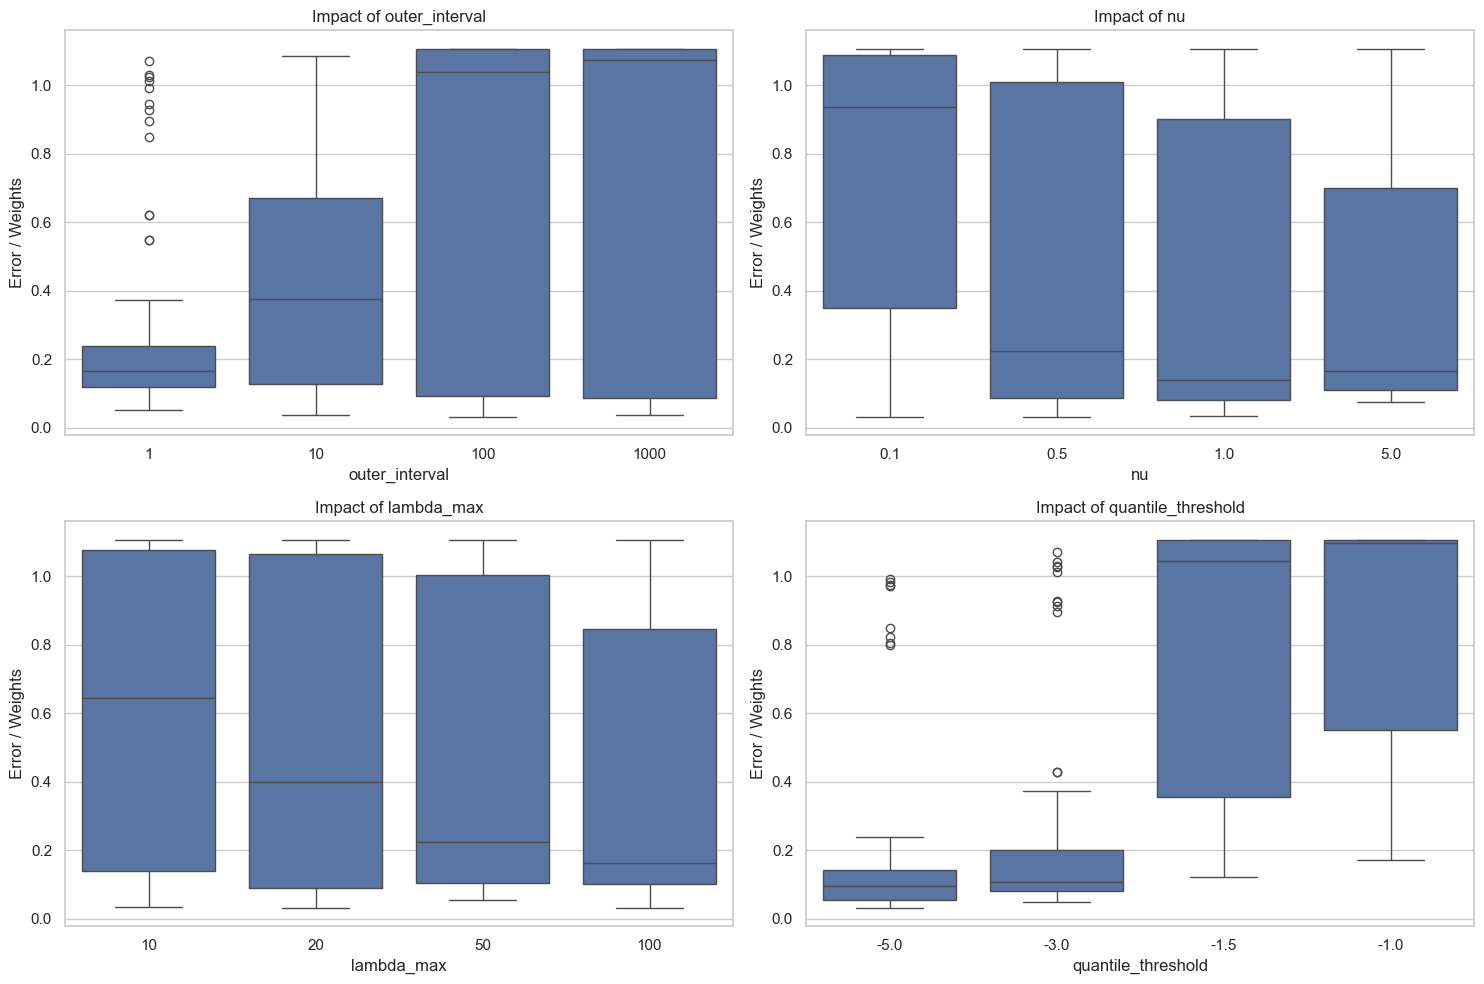

In [34]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for i, param in enumerate(sweep_params):
    sns.boxplot(x=param, y=metric_col, data=df, ax=axes[i])
    axes[i].set_title(f'Impact of {param}')
    axes[i].set_ylabel('Error / Weights')

plt.tight_layout()
plt.show()

### Interpretation
- **quantile_threshold**: Look for the value with the lowest median and quartiles. A strong trend here indicates high sensitivity.
- **lambda_max**: Does a higher penalty limit help? 
- **outer_interval**: Check if frequent updates (low interval) or sparse updates (high interval) are better.

## 4. Correlation Analysis

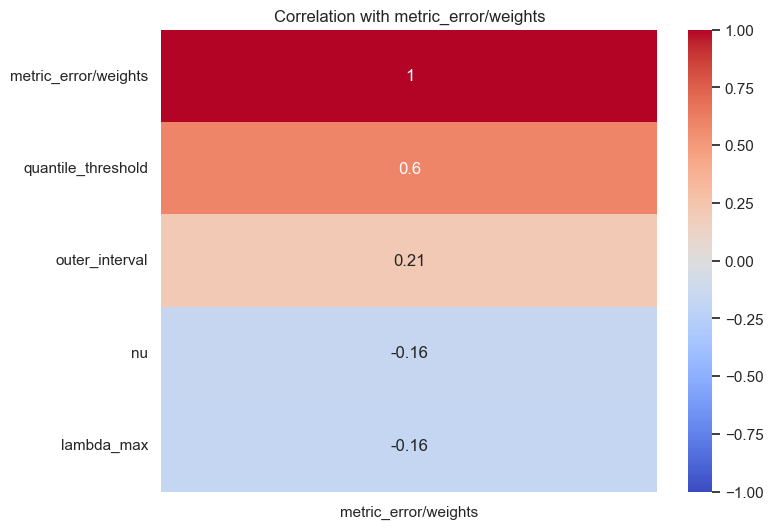

In [35]:
cols = sweep_params + [metric_col]
# Ensure all are numeric
for c in cols:
    df[c] = pd.to_numeric(df[c], errors='coerce')

corr = df[cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr[[metric_col]].sort_values(by=metric_col, ascending=False), annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title(f'Correlation with {metric_col}')
plt.show()

## 5. Top 10 Runs Analysis

In [36]:
top_10 = df.sort_values(metric_col).head(10)

print("Top 10 Runs Parameter Distribution:")
for p in sweep_params:
    print(f"\n{p}:")
    print(top_10[p].value_counts())

Top 10 Runs Parameter Distribution:

outer_interval:
outer_interval
1000    4
100     3
10      3
Name: count, dtype: int64

nu:
nu
1.0    4
0.1    3
0.5    3
Name: count, dtype: int64

lambda_max:
lambda_max
20     4
100    3
10     3
Name: count, dtype: int64

quantile_threshold:
quantile_threshold
-5.0    10
Name: count, dtype: int64


## 6. Conclusion & Recommendations

Based on the analysis above:

**1. Quantile Threshold**
Previous analysis suggests **-5.0** is significantly better. If the boxplot confirms this (much lower error for -5), specificy it as the primary choice.

**2. Other Parameters**
Check the 'Top 10' counts. The values that appear most frequently in the top performing runs are usually the most robust choices.

**Suggested Config:**
(Fill this in after running the notebook)
- quantile_threshold: 
- lambda_max: 
- outer_interval: 
- nu: 

## 7. Query Best Run by Parameter
Use the function below to find the absolute best run given a specific parameter value.

In [37]:
def find_best_run(**kwargs):
    """
    Find the best run (minimum error) matching ALL provided parameter constraints.
    Supports single or multiple parameters.
    
    Usage:
      find_best_run(quantile_threshold=-5)
      find_best_run(quantile_threshold=-5, lambda_max=100)
    """
    subset = df.copy()
    
    # 1. Apply Filters
    for param_name, param_value in kwargs.items():
        if param_name not in subset.columns:
            print(f"Warning: Parameter '{param_name}' not found in data. Ignoring.")
            continue
        
        # Be careful with types (float vs int), pandas equality usually handles mixed numeric types ok
        # but sometimes precision issues happen. Here we assume exact match.
        subset = subset[subset[param_name] == param_value]
    
    if subset.empty:
        print("No runs found matching the criteria:")
        for k, v in kwargs.items():
            print(f"  {k} = {v}")
        return None
    
    # 2. Find Min Error in Subset
    best_idx = subset[metric_col].idxmin()
    best_run = subset.loc[best_idx]
    
    # 3. Output Result
    print(f"=== Best Run matching {kwargs} ===")
    print(f"Error: {best_run[metric_col]:.6f}")
    print("Full Configuration:")
    for p in sweep_params:
        print(f"  {p}: {best_run[p]}")
    print(f"Run ID: {best_run['run_id']}")
    print("===========================================")
    print("\n")
    return None
# Example Usage:
# Single parameter query
find_best_run(outer_interval=1)
find_best_run(outer_interval=10)
find_best_run(outer_interval=100)
find_best_run(outer_interval=1000)

=== Best Run matching {'outer_interval': 1} ===
Error: 0.053570
Full Configuration:
  outer_interval: 1
  nu: 1.0
  lambda_max: 10
  quantile_threshold: -5.0
Run ID: run-20251120_094103-8qmjp9g6


=== Best Run matching {'outer_interval': 10} ===
Error: 0.037209
Full Configuration:
  outer_interval: 10
  nu: 0.1
  lambda_max: 100
  quantile_threshold: -5.0
Run ID: run-20251122_020009-6drolgs9


=== Best Run matching {'outer_interval': 100} ===
Error: 0.032950
Full Configuration:
  outer_interval: 100
  nu: 0.1
  lambda_max: 100
  quantile_threshold: -5.0
Run ID: run-20251122_025339-8psf51kl


=== Best Run matching {'outer_interval': 1000} ===
Error: 0.037232
Full Configuration:
  outer_interval: 1000
  nu: 0.1
  lambda_max: 100
  quantile_threshold: -5.0
Run ID: run-20251122_034642-rlk2ygeg


